
# Classifier comparison

**Learning Outcomes**
1. Compare different classifiers on different classification problems to appreciate their strengths and weaknesses.
2. Develop mindfulness about the differences when it comes to high dimensional datasets.


In this exercise we make a comparison of a several classifiers in scikit-learn on synthetic datasets.
The point of this example is to illustrate the nature of decision boundaries of different classifiers.
This should be taken with a grain of salt, as the intuition conveyed by these examples does not necessarily carry over to real datasets.

Particularly in high-dimensional spaces, data can more easily be separated linearly and the simplicity of classifiers such as kNN and the Perceptron might lead to better generalisation than is achieved by other classifiers.

The plots show training points in solid colours and testing points semi-transparent. The lower right shows the classification accuracy on the test set.


In [2]:
%matplotlib inline

In [3]:
# Code source: Gaël Varoquaux
#              Andreas Müller
# Modified for documentation by Jaques Grobler
# Modified slightly by Abdulrahman Altahhan
# License: BSD 3 clause

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles, make_classification

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

h = .02  # step size in the mesh



In [4]:
names = ["Nearest Neighbors", "Decision Tree", "Random Forest", "Neural Net"]

classifiers = [
    KNeighborsClassifier(3),
    DecisionTreeClassifier(max_depth=5),
    RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
    MLPClassifier(alpha=1, max_iter=1000)]

X, y = make_classification(n_features=2, n_redundant=0, n_informative=2,
                           random_state=1, n_clusters_per_class=1)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)

datasets = [make_moons(noise=0.3, random_state=0),
            make_circles(noise=0.2, factor=0.5, random_state=1),
            linearly_separable ]



C:\Users\wesle\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\wesle\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

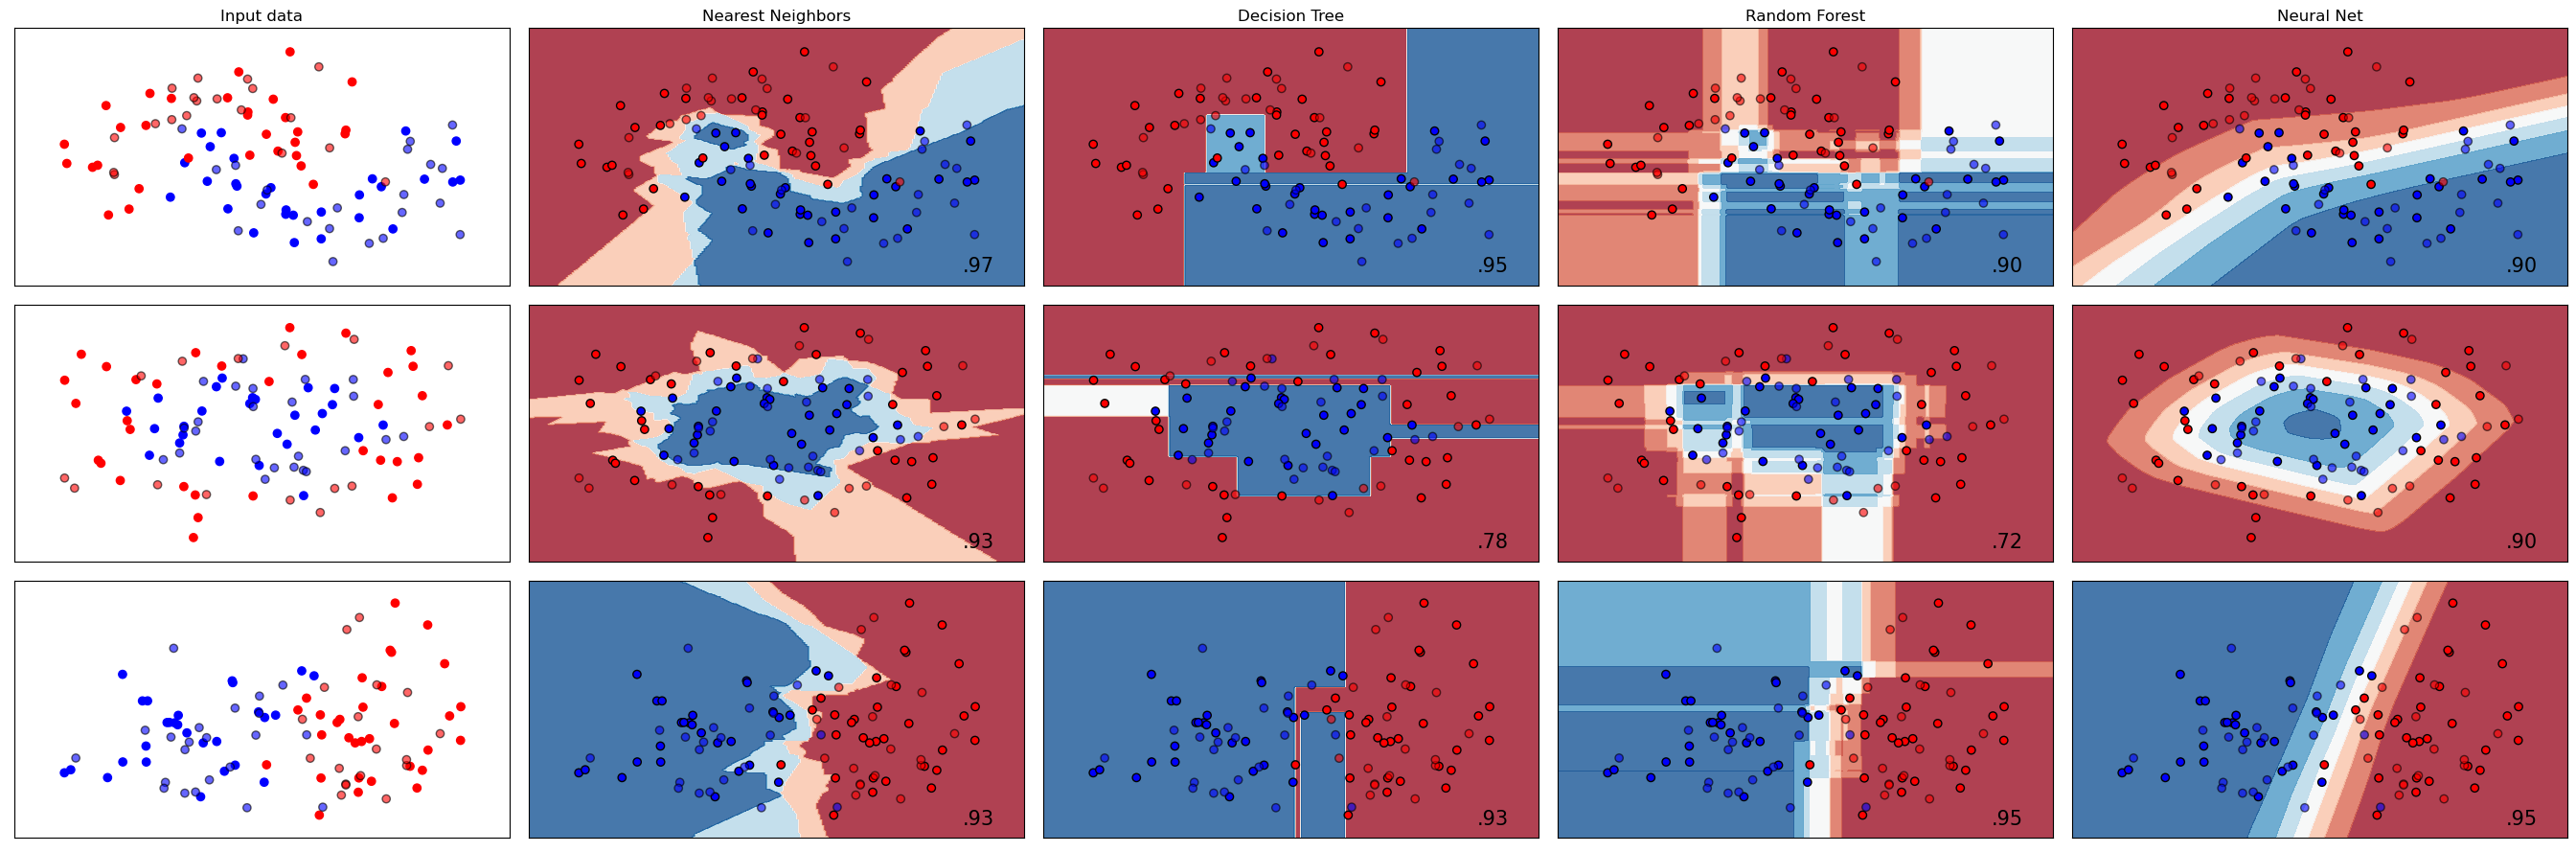

In [5]:
figure = plt.figure(figsize=(27, 9))
i = 1
# iterate over datasets
for ds_cnt, ds in enumerate(datasets):
    # preprocess dataset, split into training and test part
    X, y = ds
    X = StandardScaler().fit_transform(X)
    X_train, X_test, y_train, y_test = \
        train_test_split(X, y, test_size=.4, random_state=42)

    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # just plot the dataset first
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(['#FF0000', '#0000FF'])
    ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
    if ds_cnt == 0:       ax.set_title("Input data")
    # Plot the training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright)
    
    # Plot the testing points
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors='k')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xticks(())
    ax.set_yticks(())
    i += 1

    # iterate over classifiers
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
        clf.fit(X_train, y_train)
        score = clf.score(X_test, y_test)

        # Plot the decision boundary. For that, we will assign a color to each
        # point in the mesh [x_min, x_max]x[y_min, y_max].
        if hasattr(clf, "decision_function"):          Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
        else:                                          Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]

        # Put the result into a colour plot
        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z, cmap=cm, alpha=.8)

        # Plot the training points
        ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors='k')
        # Plot the testing points
        ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright,  edgecolors='k', alpha=0.6)

        ax.set_xlim(xx.min(), xx.max())
        ax.set_ylim(yy.min(), yy.max())
        ax.set_xticks(())
        ax.set_yticks(())
        if ds_cnt == 0:     ax.set_title(name)
        ax.text(xx.max() - .3, yy.min() + .3, ('%.2f' % score).lstrip('0'), size=15, horizontalalignment='right')
        i += 1

plt.tight_layout()
plt.show()

Note how Neural Nets and kNN can come up with arbitrary decision boundary depending on the ‎dataset, while DT Random Forest has as usual a rectilinear shape

## Your turn


1. Add a linear classifier including logistic regression, multinomial logistic regression and the perceptron



In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Perceptron

In [7]:
X, y = make_classification(n_features=3, n_redundant=0, n_informative=3,
                           random_state=1, n_clusters_per_class=1)
rng = np.random.RandomState(1)
X += 3 * rng.uniform(size=X.shape)
linearly_separable_3features = (X, y)

In [8]:
my_datasets = datasets.copy()
#my_datasets.append(linearly_separable_3features)

In [9]:
print(len(datasets))
print(len(my_datasets))

3
3


In [10]:
classifiers = [LogisticRegression(solver='liblinear'), Perceptron(early_stopping=True)]
names=['LogisticRegression', 'Perceptron']

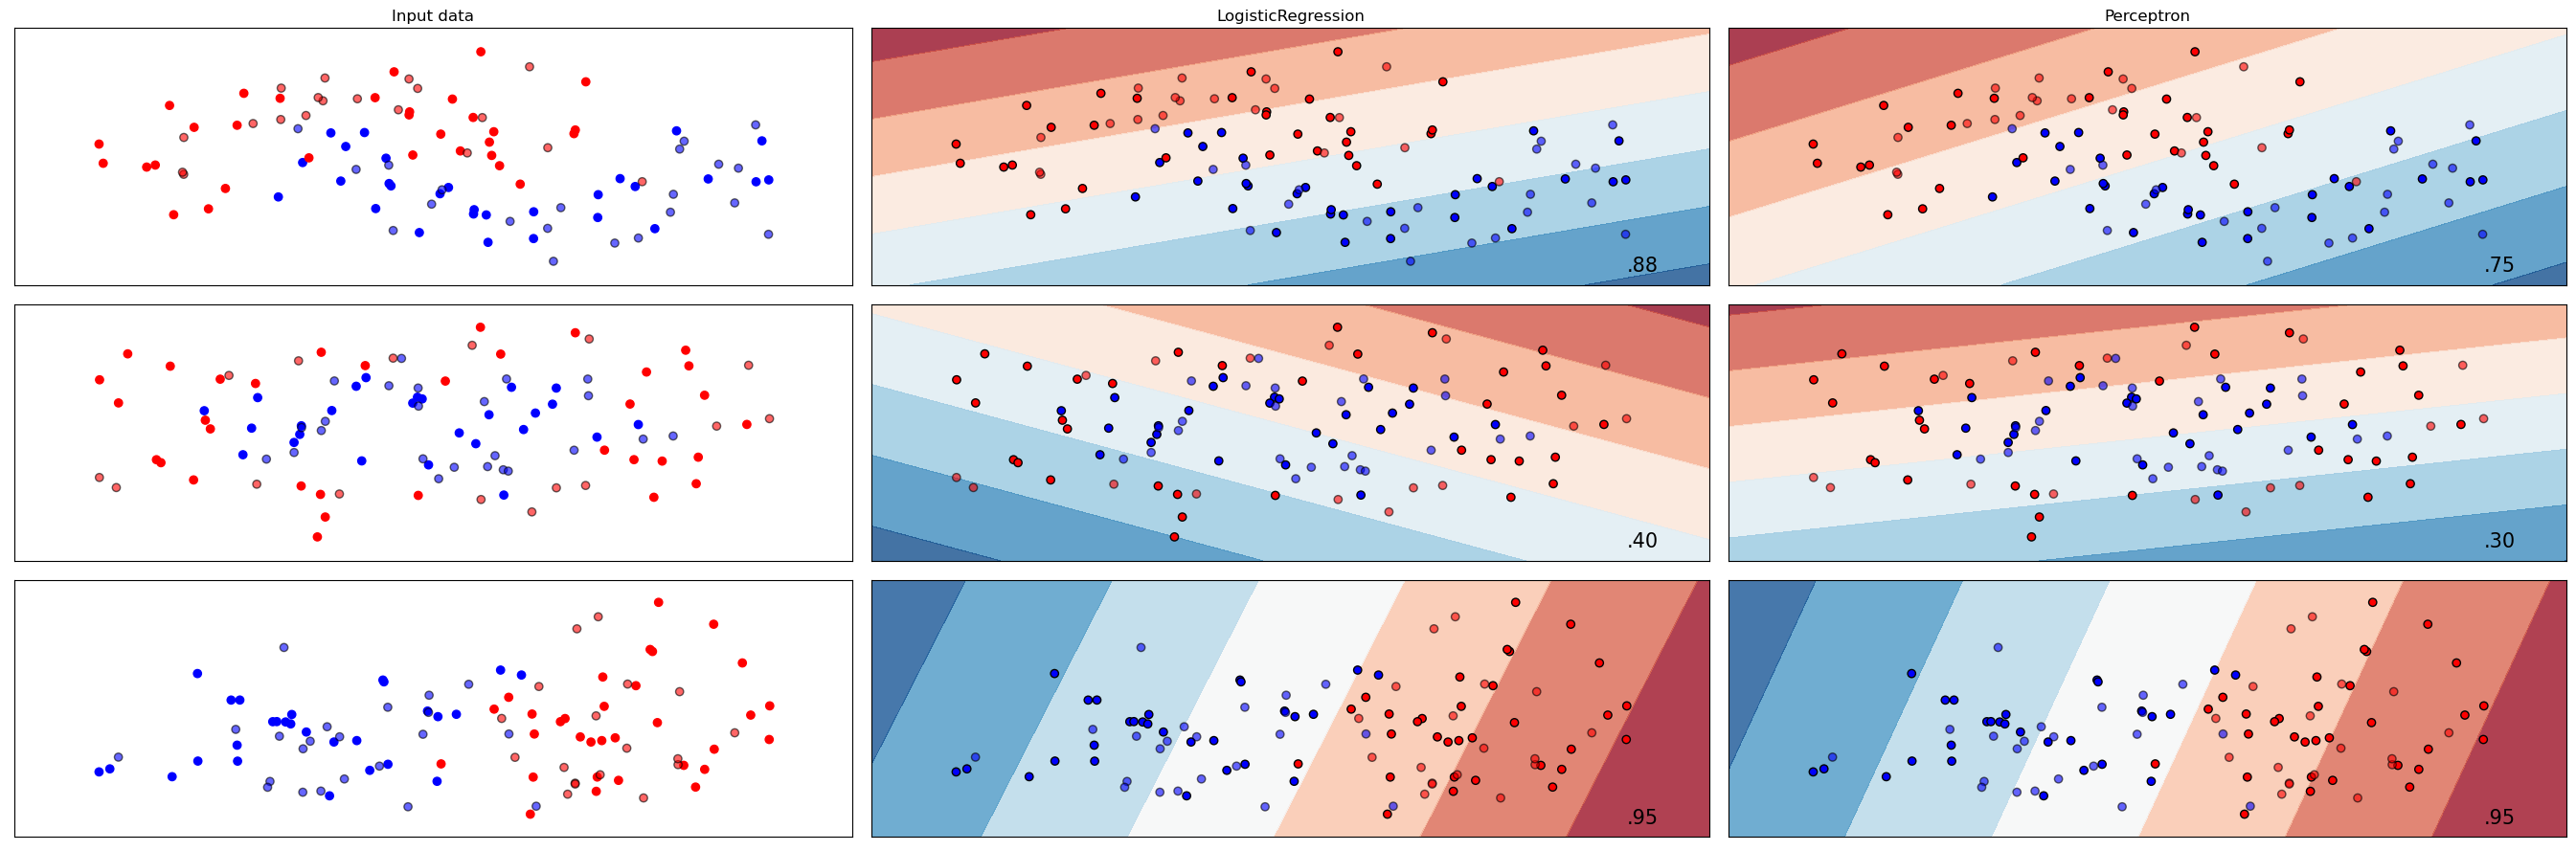

In [11]:
figure = plt.figure(figsize=(27, 9))
i = 1
# iterate over datasets
for ds_cnt, ds in enumerate(my_datasets):
    # preprocess dataset, split into training and test part
    X, y = ds
    X = StandardScaler().fit_transform(X)
    X_train, X_test, y_train, y_test = \
        train_test_split(X, y, test_size=.4, random_state=42)
    
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # just plot the dataset first
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(['#FF0000', '#0000FF'])
    ax = plt.subplot(len(my_datasets), len(classifiers) + 1, i)
    if ds_cnt == 0:       ax.set_title("Input data")
    # Plot the training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright)
    
    # Plot the testing points
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors='k')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xticks(())
    ax.set_yticks(())
    i += 1

    # iterate over classifiers
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(my_datasets), len(classifiers) + 1, i)
        clf.fit(X_train, y_train)
        score = clf.score(X_test, y_test)

        # Plot the decision boundary. For that, we will assign a color to each
        # point in the mesh [x_min, x_max]x[y_min, y_max].
        if hasattr(clf, "decision_function"):          Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
        else:                                          Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]

        # Put the result into a colour plot
        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z, cmap=cm, alpha=.8)

        # Plot the training points
        ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors='k')
        # Plot the testing points
        ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright,  edgecolors='k', alpha=0.6)

        ax.set_xlim(xx.min(), xx.max())
        ax.set_ylim(yy.min(), yy.max())
        ax.set_xticks(())
        ax.set_yticks(())
        if ds_cnt == 0:     ax.set_title(name)
        ax.text(xx.max() - .3, yy.min() + .3, ('%.2f' % score).lstrip('0'), size=15, horizontalalignment='right')
        i += 1

plt.tight_layout()
plt.show()

2. Tackle higher dimensional dataset by changing n_features and compare the performance of the classifiers using our usual metrics such as the F1 measure and the balanced accuracy etc.

['LogisticRegression', 'Perceptron']


"'\nfor name, clf in zip(names, classifiers):\n        #ax = plt.subplot(len(my_datasets), len(classifiers) + 1, i)\n        clf.fit(X_train, y_train)\n        score = clf.score(X_test, y_test)\n"

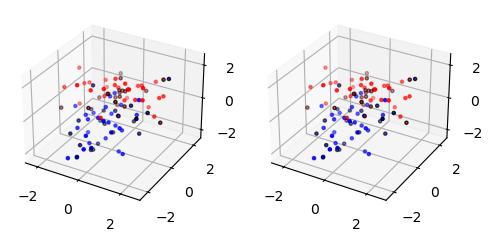

In [44]:
X, y = linearly_separable_3features
X = StandardScaler().fit_transform(X)
x1_min, x1_max = X[:, 0].min(), X[:, 0].max()
x2_min, x2_max = X[:, 1].min(), X[:, 1].max()
x3_min, x3_max = X[:, 2].min(), X[:, 2].max()

xx1, xx2, yy = np.meshgrid(np.arange(x1_min, x1_max, h),
                           np.arange(x2_min, x2_max, h),
                           np.arange(y.min(), y.max()))

cm = plt.cm.RdBu
cm_bright = ListedColormap(['#FF0000', '#0000FF'])
X_train, X_test, y_train, y_test = \
        train_test_split(X, y, test_size=.4, random_state=42)

print(names)
#print(classifiers)

fig = plt.figure(figsize = (9,9))
ax = plt.subplot(len(my_datasets), len(classifiers) + 1, 1, projection='3d')
#ax = fig.add_subplot(projection='3d')
ax.scatter(X_train[:,0], X_train[:,1], X_train[:, 2], c=y_train, cmap=cm_bright, s=5)
ax.scatter(X_test[:,0], X_test[:,1], X_test[:, 2], c=y_test, cmap=cm_bright, s=5, edgecolors='k')

#ax_logreg = plt.subplot(len(my_datasets), len(classifiers) + 1, 2, projection='3d')

clf_logreg = classifiers[0].fit(X_train, y_train)
clf_perceptron = classifiers[1].fit(X_train, y_train)

ax_logreg = plt.subplot(len(my_datasets), len(classifiers) + 1, 2, projection='3d')
ax_logreg.scatter(X_train[:,0], X_train[:,1], X_train[:, 2], c=y_train, cmap=cm_bright, s=5)
ax_logreg.scatter(X_test[:,0], X_test[:,1], X_test[:, 2], c=y_test, cmap=cm_bright, s=5, edgecolors='k')

if hasattr(clf_logreg, "decision_function"):          Z = clf_logreg.decision_function(np.c_[xx.ravel(), yy.ravel()])
else:                                          Z = clf_logreg.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]

# Put the result into a colour plot
Z = Z.reshape(xx.shape)
ax.contourf(xx, yy, Z, cmap=cm, alpha=.8)

''''
for name, clf in zip(names, classifiers):
        #ax = plt.subplot(len(my_datasets), len(classifiers) + 1, i)
        clf.fit(X_train, y_train)
        score = clf.score(X_test, y_test)
'''


#plt.show()
